# Assignment 1: Exploring single qubit quantum circuits with PennyLane


In [9]:
import pennylane as qml # why are we using qml instead of qml
from pennylane import numpy as np

## Task 1: HXH
1a) Create a device with one qubit. Then, write a QNode (from scratch!) that applies the following circuit and returns the state.

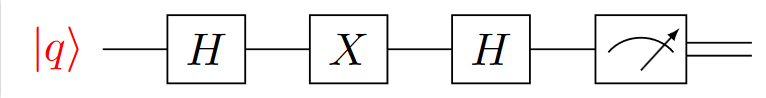

1b) Determine its effect on the two basis states. What does this operation do?

The signature of your function should be:
```
def apply_hxh(state):
    ...
    return qml.state()

```

Here, ```state``` is a flag which prepares $|1\rangle$ if ```state=1```, and $0\rangle$ otherwise.

In [22]:
##################
# YOUR CODE HERE #
##################

# CREATE A DEVICE
dev = qml.device("default.qubit", wires=1)

# CREATE A QNODE CALLED apply_hxh THAT APPLIES THE CIRCUIT ABOVE
@qml.qnode(dev)
def apply_hxh(state):
    if state:
        qml.PauliX(0)
    qml.Hadamard(0)
    qml.PauliX(0)
    qml.Hadamard(0)
    return qml.state()

# Print your results
print(apply_hxh(0))
print(apply_hxh(1))

[1.+0.j 0.+0.j]
[ 0.+0.j -1.+0.j]


**Your 1b answer here**

We first apply the Hadamard gate to put the state in an equal superposition (either plus or minus). Applying X, we flip the value of both components of the superposition, yielding no change in the $\ket{+}$ case, and introduces a negative phase in the $\ket{-}$ case. 

Applying H again, we recieve our original input with a negative phase, if and only if 1 was inputted.  Input 0 will not encounter a phase change. 

Note that this is the same as applying the Z gate. 

## Task 2: Jumble

The code below is a quantum function with all the gates from the circuit shown below. However, the gates are out of order! Re-arrange the lines of the function to match the order of operations in the circuit.

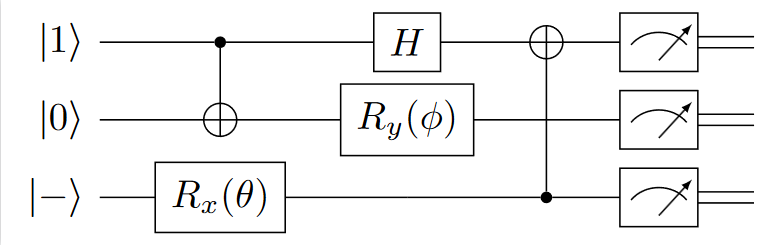


In [21]:
def my_circuit(theta, phi):
    ##################
    # YOUR CODE HERE #
    ##################

    # REORDER THESE GATES TO MATCH THE CIRCUIT IN THE PICTURE

    # initalize states
    qml.PauliX(0) #q0 to 1
    
    qml.PauliX(2)
    qml.Hadamard(2) #q2 to -

    # --------------------

    # first set of gates
    qml.CNOT(wires=[0, 1])
    qml.RX(theta, wires=2)

    # second set of gates
    qml.Hadamard(wires=0)
    qml.RY(phi, wires=1)

    # last set of gates
    qml.CNOT(wires=[2, 0])
    
    # This is the measurement; we return the probabilities of all possible output states
    return qml.probs(wires=[0, 1, 2])

In [7]:
print(qml.draw(my_circuit)(theta=1, phi=2))

0: ──X─╭●──H────────╭X─┤ ╭Probs
1: ────╰X──RY(2.00)─│──┤ ├Probs
2: ──X──H──RX(1.00)─╰●─┤ ╰Probs


## Task 3: Rotations

3a) Write a QNode that applies ```qml.RX``` with an angle of $\pi$ to one of the computational basis states. 

3b) What operation is this?

In [ ]:
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def apply_rx_pi(state):
    """Apply an RX gate with an angle of \pi to a particular basis state.

    Args:
        state (int): Either 0 or 1. If 1, initialize the qubit to state |1>
            before applying other operations.

    Returns:
        np.array[complex]: The state of the qubit after the operations.
    """
    ##################
    # YOUR CODE HERE #
    ##################
    # PREPARE STATE
    if state: 
        qml.PauliX(0)
    # APPLY RX(pi) AND RETURN THE STATE
    qml.RX(np.pi, 0)
    return qml.state()


print(apply_rx_pi(0)) 
print(apply_rx_pi(1))


[6.123234e-17+0.j 0.000000e+00-1.j]
[0.000000e+00-1.j 6.123234e-17+0.j]


**Your 3b answer here**

RX is a generic rotation about the X axis. If we rotate by $\pi$, then we have done the same thing as an X gate, with a global phase factor of $-i$. We can verify this by plugging in $\pi$ and simplyifing the RX matrix definition. In practice this should not change much as the measurement probabilities will be the same as applying X. (we should do this only if we need to apply a phase for some good reason, like applying interference)

## Task 4: Rotations
The Pauli-$Z$ gate is defined by its action on the computational basis states:
$$
|0\rangle \rightarrow |0\rangle 
$$

$$
|1\rangle \rightarrow -|1\rangle
$$

4a) Write a QNode that applies qml.PauliZ to the $|-\rangle$ state and returns the state. 

4b) What state is this? How do the measurement probabilities differ from those of the state $|-\rangle$?


In [14]:
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def apply_z_to_minus():
    """Write a circuit that applies PauliZ to the |-> state and returns
    the state.

    Returns:
        np.array[complex]: The state of the qubit after the operations.
    """

    ##################
    # YOUR CODE HERE #
    ##################

    # CREATE THE |-> STATE
    qml.PauliX(0)
    qml.Hadamard(0)
    # APPLY PAULI Z
    qml.PauliZ(0)
    # RETURN THE STATE
    return qml.state()


print(apply_z_to_minus())

[0.70710678+0.j 0.70710678-0.j]


**Your 4b answer here**
Applying Z linearly to the superposition $\ket{-} = \frac{1}{\sqrt{2}} \left[ \ket{0} - \ket{1} \right] $ yields a phase flip on the (currently negative) $\ket{1}$ term. This relative phase flip changes the state from $\ket{-}$ to $\ket{+}$. 

# Task 5: There is an imposter among us

The single qubit Z rotation
$$ R_z(\phi) = e^{-i\phi\sigma_z/2} = \begin{bmatrix}
                e^{-i\phi/2} & 0 \\
                0 & e^{i\phi/2}
            \end{bmatrix}$$

In PennyLane, this operation is accessible as ```qml.RZ```, which is a parametrized operation, and so we must specify not only a wire, but an angle of rotation:   
```
qml.RZ(angle, wires=wire)
```
Write a QNode that uses ```qml.RZ``` to simulate a ```qml.PauliZ``` operation and return the state. Apply it to the $|+\rangle$ state to check your work.

In [29]:
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def imposter_z():
    """Use RZ to produce the same action as Pauli Z on the |+> state.

    Returns:
        np.array[complex]: The state of the qubit after the operations.
    """

    ##################
    # YOUR CODE HERE #
    ##################

    # CREATE THE |+> STATE
    qml.Hadamard(0)
    # APPLY RZ
    qml.RZ(np.pi, wires=0)
    # RETURN THE STATE
    return qml.state()

print(imposter_z())

[4.32978028e-17-0.70710678j 4.32978028e-17+0.70710678j]


## Task 6: Measurement

So far, we have looked at a qubit's statevector, now let's look at probabilities. We've learned that the different outcome probabilities are related to the amplitudes of a qubit's state vector. If no measurement basis is specified, in PennyLane, measurement is done in the computational basis (also called the $Z$-basis).  


6a) Write a simple circuit that applies a Hadamard gate to either $|0\rangle$ or $1\rangle$, and returns the measurement outcome probabilities. 

6b) Analyze what a Z-basis measurement reveals about this  quantum state (pre-measurement):
- What information can we extract about the state's amplitudes?
- What aspects of the quantum state remain unknown after measurement? 

In [30]:
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def apply_h_and_measure(state):
    """Complete the function such that we apply the Hadamard gate
    and measure in the computational basis.

    Args:
        state (int): Either 0 or 1. If 1, prepare the qubit in state |1>,
            otherwise leave it in state 0.

    Returns:
        np.array[float]: The measurement outcome probabilities.
    """
    ##################
    # YOUR CODE HERE #
    ##################
    
    # PREPARE STATE
    if state:
        qml.PauliX(0)
    # APPLY HADAMARD AND MEASURE
    qml.Hadamard(0)
    return qml.probs(wires=0)


print(apply_h_and_measure(0))
print(apply_h_and_measure(1))

[0.5 0.5]
[0.5 0.5]


**Your 6b answer here**

From the Z-basis measurements we made, we know the following facts:
- The state is in an equal superposition of $\ket{0}$ and $\ket{1}$. 
- The magnitudes of the probability amplitudes are equal.

However, we know nothing about the relative phase between the components. This means it's impossible to distinguish between the original state being $\ket{+}$ and $\ket{-}$. 